K-Means clustering work with logistic regression and SVC for baselines. Made with help, but not by, our good friend claude so feeling very old school rn. Shame I think its synthetic. Classification is at the top cluster looking at is at the bottom. 

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, f1_score, roc_auc_score
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [3]:
df = pd.read_csv('startup_success_dataset.csv')

In [4]:
df.describe()


,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05
mean,2.002300,12.024300,150.732000,33.203875,285422.832730,16.776213,7.828191e+05
std,1.414671,7.208089,86.272631,43.034753,159323.885405,15.711368,6.085069e+05
min,0.000000,0.000000,2.000000,0.288738,668.000000,0.279763,1.344810e+03
25%,1.000000,6.000000,76.000000,10.196778,161194.750000,7.087591,3.154861e+05
50%,2.000000,12.000000,151.000000,20.158063,264989.500000,12.169059,6.213624e+05
75%,3.000000,18.000000,226.000000,39.531967,389214.000000,20.953561,1.098921e+06
max,8.000000,24.000000,299.000000,1072.434476,915203.000000,357.491454,4.168443e+06


In [5]:
df.nunique()

funding_rounds                   9
founder_experience_years        25
team_size                      298
market_size_billion         100000
product_traction_users       91579
burn_rate_million           100000
revenue_million             100000
investor_type                    4
sector                           7
founder_background               4
outcome                          3
dtype: int64

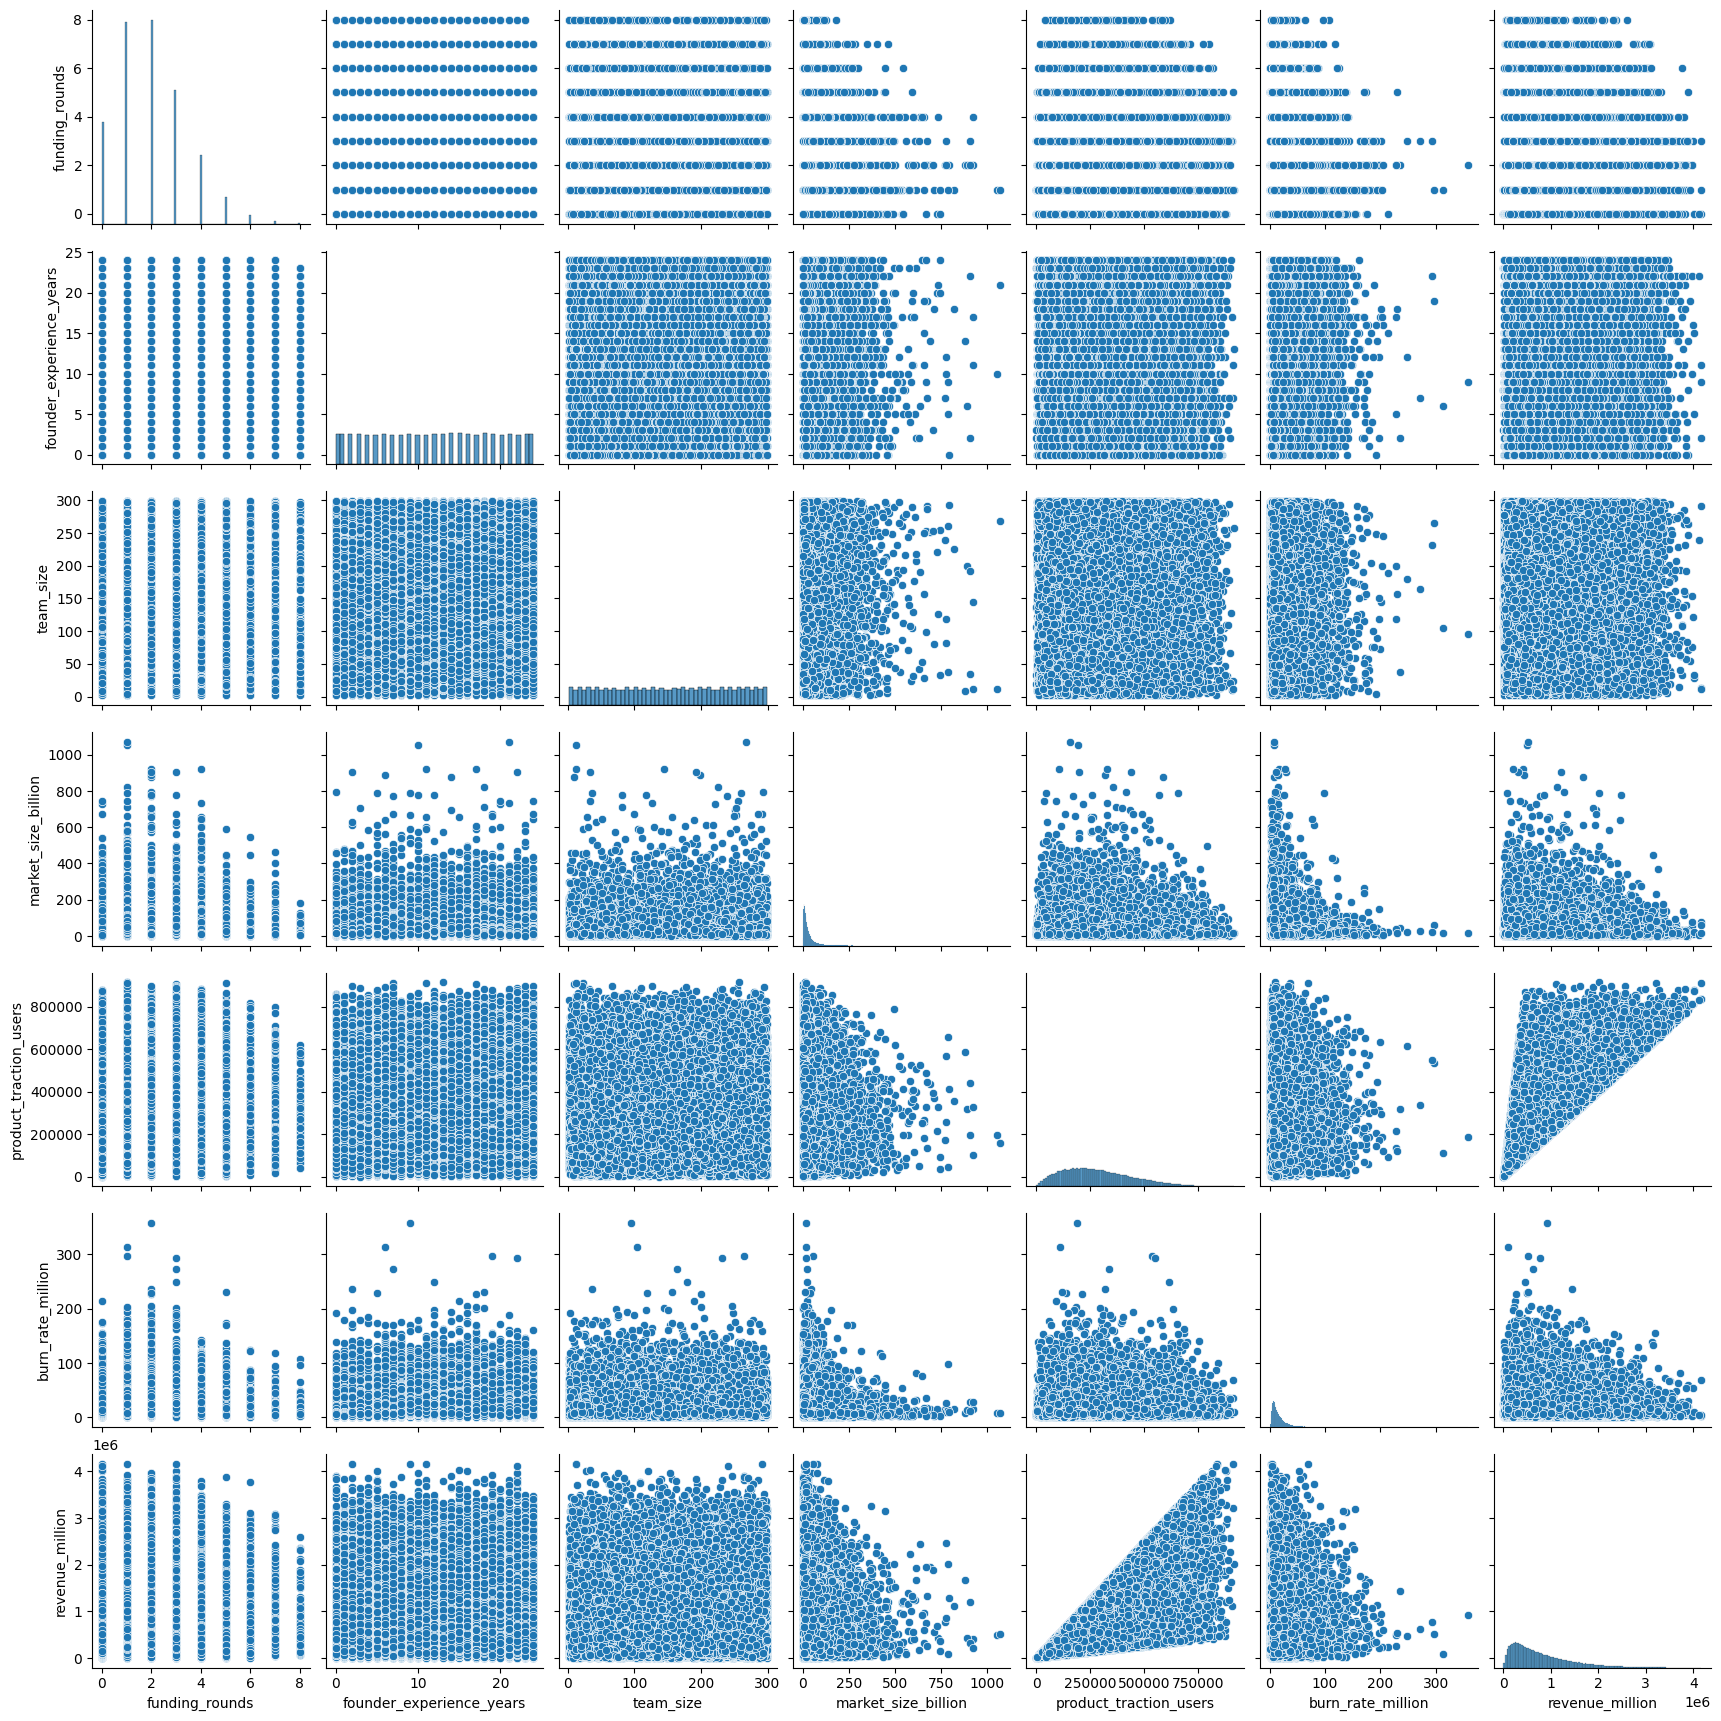

In [6]:
sns.pairplot(df)


In [7]:
print(df['founder_background'].value_counts())
print("\n")

print(df['investor_type'].value_counts())
print("\n")

print(df['sector'].value_counts())
print("\n")

print(df['outcome'].value_counts())
print("\n")

founder_background
first_time        39980
ex_bigtech        25009
academic          20054
serial_founder    14957
Name: count, dtype: int64


investor_type
tier2_vc    35327
angel       25137
none        24866
tier1_vc    14670
Name: count, dtype: int64


sector
Crypto       14456
Climate      14412
Health       14357
SaaS         14333
Fintech      14220
Ecommerce    14148
AI           14074
Name: count, dtype: int64


outcome
Failure        55610
Acquisition    42335
IPO             2055
Name: count, dtype: int64




outcome
Failure        55610
Acquisition    42335
IPO             2055
Name: count, dtype: int64

outcome
Failure        0.55610
Acquisition    0.42335
IPO            0.02055
Name: proportion, dtype: float64

<Axes: xlabel='outcome', ylabel='count'>

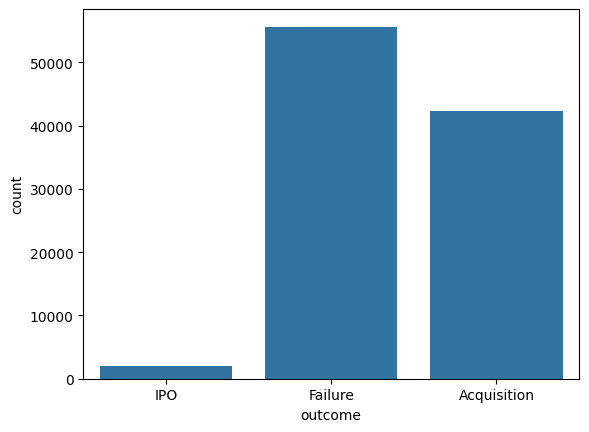

In [8]:
display(df['outcome'].value_counts())
display(df['outcome'].value_counts(normalize=True))
sns.countplot(x='outcome', data=df)

In [9]:
X = df.drop(columns=['outcome'])
y = df['outcome']

In [10]:
class_names = df['outcome'].unique().tolist()  # do this BEFORE label encoding
le = LabelEncoder()
y = le.fit_transform(y)
print(le.classes_)

['Acquisition' 'Failure' 'IPO']


In [11]:
X = pd.get_dummies(X, columns=['investor_type', 'sector', 'founder_background'], drop_first=True)

In [12]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=1, stratify=y
)

# Step 2: split the 30% temp into 15% val and 15% test (i.e. 50/50 of temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=1, stratify=y_temp
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)
np.unique(y, return_counts=True)

(array([0, 1, 2]), array([42335, 55610,  2055]))

In [13]:
np.unique(y_test, return_counts=True)
np.unique(y_train, return_counts=True)
np.unique(y_val, return_counts=True)

(array([0, 1, 2]), array([6350, 8342,  308]))

In [16]:
lr = LogisticRegression(
    max_iter=1000,              # give it enough iterations to converge
    random_state=1)
lr.fit(X_train_scaled, y_train)

svm = SVC(
    kernel='rbf',          # radial basis function - good default for tabular data
    probability=True,      # needed later for AUC calculation
    random_state=1
)
svm.fit(X_train_scaled, y_train)

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),  # two hidden layers
    max_iter=100,
    early_stopping=True,           # stops if validation loss plateaus
    random_state=1
)
mlp.fit(X_train_scaled, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",100
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",1


In [15]:
# Predictions
for model in [lr, svm, mlp]:
    y_pred = model.predict(X_val_scaled)
    y_prob = model.predict_proba(X_val_scaled)  # for AUC

    # Metrics
    print(f"Model: {model.__class__.__name__}")
    print(classification_report(y_val, y_pred, target_names=['Acquisition', 'Failure', 'IPO']))
    print("F1 Macro:", f1_score(y_val, y_pred, average='macro'))
    print("ROC-AUC:", roc_auc_score(y_val, y_prob, multi_class='ovr', average='macro'))

Model: LogisticRegression
              precision    recall  f1-score   support

 Acquisition       0.66      0.56      0.61      6350
     Failure       0.79      0.78      0.78      8342
         IPO       0.18      0.81      0.29       308

    accuracy                           0.69     15000
   macro avg       0.54      0.72      0.56     15000
weighted avg       0.72      0.69      0.70     15000

F1 Macro: 0.5620214591519085
ROC-AUC: 0.8454068613265848
Model: SVC
              precision    recall  f1-score   support

 Acquisition       0.66      0.58      0.62      6350
     Failure       0.79      0.78      0.78      8342
         IPO       0.18      0.71      0.29       308

    accuracy                           0.69     15000
   macro avg       0.54      0.69      0.56     15000
weighted avg       0.72      0.69      0.70     15000

F1 Macro: 0.5641194008271628
ROC-AUC: 0.8606693022471384
Model: MLPClassifier
              precision    recall  f1-score   support

 Acquisitio

In [18]:
# K-Means time
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=1, n_init=10)
    km.fit(X_train_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_train_scaled, km.labels_))


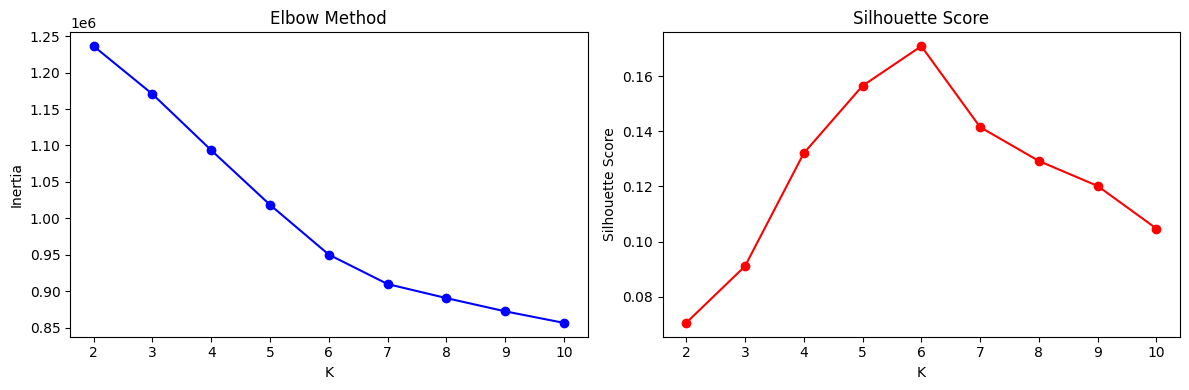

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('K')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')

ax2.plot(K_range, silhouettes, 'ro-')
ax2.set_xlabel('K')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')

plt.tight_layout()
plt.show()

In [ ]:
# Fit final K-Means on training data only
km_final = KMeans(n_clusters=6, random_state=1, n_init=10)
km_final.fit(X_train_scaled)

# Get cluster labels for all three splits
train_clusters = km_final.predict(X_train_scaled)
val_clusters   = km_final.predict(X_val_scaled)
test_clusters  = km_final.predict(X_test_scaled)

In [21]:
# Reshape cluster labels and concatenate to scaled feature matrices
def add_cluster_feature(X_scaled, clusters, n_clusters=6):
    # One-hot encode the cluster labels
    cluster_ohe = np.zeros((len(clusters), n_clusters))
    for i, c in enumerate(clusters):
        cluster_ohe[i, c] = 1
    return np.hstack([X_scaled, cluster_ohe])

X_train_hybrid = add_cluster_feature(X_train_scaled, train_clusters)
X_val_hybrid   = add_cluster_feature(X_val_scaled,   val_clusters)
X_test_hybrid  = add_cluster_feature(X_test_scaled,  test_clusters)

print(X_train_hybrid.shape)  # should be (70000, original_features + 6)

(70000, 25)


In [23]:
# K-Means + Logistic Regression
lr_hybrid = LogisticRegression(
                                max_iter=1000, random_state=1)
lr_hybrid.fit(X_train_hybrid, y_train)

# K-Means + SVM
svm_hybrid = SVC(kernel='rbf', probability=True, random_state=1)
svm_hybrid.fit(X_train_hybrid, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [24]:
for name, model in [('LR + KMeans', lr_hybrid), ('SVM + KMeans', svm_hybrid)]:
    y_pred = model.predict(X_val_hybrid)
    y_prob = model.predict_proba(X_val_hybrid)
    print(f"Model: {name}")
    print(classification_report(y_val, y_pred, 
                                 target_names=['Acquisition', 'Failure', 'IPO']))
    print("F1 Macro:", f1_score(y_val, y_pred, average='macro'))
    print("ROC-AUC:", roc_auc_score(y_val, y_prob, 
                                     multi_class='ovr', average='macro'))

Model: LR + KMeans
              precision    recall  f1-score   support

 Acquisition       0.71      0.66      0.68      6350
     Failure       0.76      0.83      0.79      8342
         IPO       0.63      0.23      0.33       308

    accuracy                           0.74     15000
   macro avg       0.70      0.57      0.60     15000
weighted avg       0.74      0.74      0.74     15000

F1 Macro: 0.6046283323256089
ROC-AUC: 0.8709648491436196
Model: SVM + KMeans
              precision    recall  f1-score   support

 Acquisition       0.73      0.63      0.68      6350
     Failure       0.75      0.85      0.80      8342
         IPO       0.83      0.11      0.20       308

    accuracy                           0.74     15000
   macro avg       0.77      0.53      0.56     15000
weighted avg       0.74      0.74      0.74     15000

F1 Macro: 0.5586038273057594
ROC-AUC: 0.8606873749643634


In [25]:
# Distance to each centroid as features (6 new columns)
train_distances = km_final.transform(X_train_scaled)  # shape (70000, 6)
val_distances   = km_final.transform(X_val_scaled)
test_distances  = km_final.transform(X_test_scaled)

# Concatenate distances instead of OHE cluster label
X_train_hybrid2 = np.hstack([X_train_scaled, train_distances])
X_val_hybrid2   = np.hstack([X_val_scaled,   val_distances])
X_test_hybrid2  = np.hstack([X_test_scaled,  test_distances])

In [26]:
# K-Means + Logistic Regression
lr_hybrid2 = LogisticRegression(
                                max_iter=1000, random_state=1)
lr_hybrid2.fit(X_train_hybrid2, y_train)

# K-Means + SVM
svm_hybrid2 = SVC(kernel='rbf', probability=True, random_state=1)
svm_hybrid2.fit(X_train_hybrid2, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [27]:
for name, model in [('LR + KMeans', lr_hybrid2), ('SVM + KMeans', svm_hybrid2)]:
    y_pred = model.predict(X_val_hybrid2)
    y_prob = model.predict_proba(X_val_hybrid2)
    print(f"Model: {name}")
    print(classification_report(y_val, y_pred, 
                                 target_names=['Acquisition', 'Failure', 'IPO']))
    print("F1 Macro:", f1_score(y_val, y_pred, average='macro'))
    print("ROC-AUC:", roc_auc_score(y_val, y_prob, 
                                     multi_class='ovr', average='macro'))

Model: LR + KMeans
              precision    recall  f1-score   support

 Acquisition       0.71      0.66      0.68      6350
     Failure       0.76      0.83      0.79      8342
         IPO       0.64      0.23      0.34       308

    accuracy                           0.74     15000
   macro avg       0.71      0.57      0.61     15000
weighted avg       0.74      0.74      0.74     15000

F1 Macro: 0.6070340326407028
ROC-AUC: 0.8707937022630544
Model: SVM + KMeans
              precision    recall  f1-score   support

 Acquisition       0.72      0.63      0.67      6350
     Failure       0.75      0.85      0.80      8342
         IPO       0.83      0.03      0.06       308

    accuracy                           0.74     15000
   macro avg       0.77      0.51      0.51     15000
weighted avg       0.74      0.74      0.73     15000

F1 Macro: 0.5120267075686745
ROC-AUC: 0.8675638564578804


In [28]:
for name, model, X in [
    ('LR Baseline',   lr,        X_test_scaled),
    ('LR + KMeans',   lr_hybrid, X_test_hybrid),
    ('SVM Baseline',  svm,       X_test_scaled),
    ('SVM + KMeans',  svm_hybrid,X_test_hybrid),
]:
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)
    print(f"\nModel: {name}")
    print(classification_report(y_test, y_pred,
                                target_names=['Acquisition', 'Failure', 'IPO']))
    print("F1 Macro:", f1_score(y_test, y_pred, average='macro'))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob,
                                     multi_class='ovr', average='macro'))


Model: LR Baseline
              precision    recall  f1-score   support

 Acquisition       0.71      0.65      0.68      6350
     Failure       0.76      0.82      0.79      8341
         IPO       0.63      0.21      0.32       309

    accuracy                           0.74     15000
   macro avg       0.70      0.56      0.59     15000
weighted avg       0.73      0.74      0.73     15000

F1 Macro: 0.5932550641069128
ROC-AUC: 0.8659633181501176

Model: LR + KMeans
              precision    recall  f1-score   support

 Acquisition       0.71      0.65      0.68      6350
     Failure       0.76      0.82      0.79      8341
         IPO       0.63      0.21      0.32       309

    accuracy                           0.74     15000
   macro avg       0.70      0.56      0.59     15000
weighted avg       0.73      0.74      0.73     15000

F1 Macro: 0.5948767664015426
ROC-AUC: 0.8659703750226434

Model: SVM Baseline
              precision    recall  f1-score   support

 Acquisi

In [29]:
unique, counts = np.unique(train_clusters, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count} samples ({count/len(train_clusters)*100:.1f}%)")

Cluster 0: 10013 samples (14.3%)
Cluster 1: 9865 samples (14.1%)
Cluster 2: 10086 samples (14.4%)
Cluster 3: 9930 samples (14.2%)
Cluster 4: 10099 samples (14.4%)
Cluster 5: 20007 samples (28.6%)


In [ ]:
feature_names = X_train.columns.tolist()

centroids_original = scaler.inverse_transform(km_final.cluster_centers_)
centroids_df = pd.DataFrame(centroids_original, columns=feature_names)
print(centroids_df.round(2))

   funding_rounds  founder_experience_years  team_size  market_size_billion  \
0            2.00                     11.93     151.02                33.12   
1            1.98                     12.15     150.30                32.68   
2            1.99                     11.96     151.29                33.79   
3            2.03                     12.10     149.34                33.79   
4            2.01                     11.87     149.19                33.43   
5            2.00                     12.02     151.69                33.31   

   product_traction_users  burn_rate_million  revenue_million  \
0               286265.35              16.50        786510.99   
1               286854.26              16.72        785775.17   
2               285841.80              16.83        792033.83   
3               285556.21              16.94        780746.29   
4               284252.93              16.70        777527.01   
5               285240.03              17.06        7836

In [31]:
numeric_cols = ['funding_rounds', 'founder_experience_years', 'team_size',
                'market_size_billion', 'product_traction_users', 
                'burn_rate_million', 'revenue_million']

print(centroids_df[numeric_cols].round(2))

   funding_rounds  founder_experience_years  team_size  market_size_billion  \
0            2.00                     11.93     151.02                33.12   
1            1.98                     12.15     150.30                32.68   
2            1.99                     11.96     151.29                33.79   
3            2.03                     12.10     149.34                33.79   
4            2.01                     11.87     149.19                33.43   
5            2.00                     12.02     151.69                33.31   

   product_traction_users  burn_rate_million  revenue_million  
0               286265.35              16.50        786510.99  
1               286854.26              16.72        785775.17  
2               285841.80              16.83        792033.83  
3               285556.21              16.94        780746.29  
4               284252.93              16.70        777527.01  
5               285240.03              17.06        783642.84 

In [32]:
# Add cluster labels back to training dataframe
X_train_copy = X_train.copy()
X_train_copy['cluster'] = train_clusters
X_train_copy['outcome'] = y_train

# Outcome distribution per cluster
outcome_dist = X_train_copy.groupby('cluster')['outcome'].value_counts(normalize=True).unstack()
outcome_dist.columns = ['Acquisition', 'Failure', 'IPO']  # adjust if order differs
print(outcome_dist.round(3))

         Acquisition  Failure    IPO
cluster                             
0              0.427    0.552  0.022
1              0.427    0.554  0.019
2              0.422    0.556  0.022
3              0.418    0.559  0.023
4              0.418    0.563  0.020
5              0.426    0.555  0.019


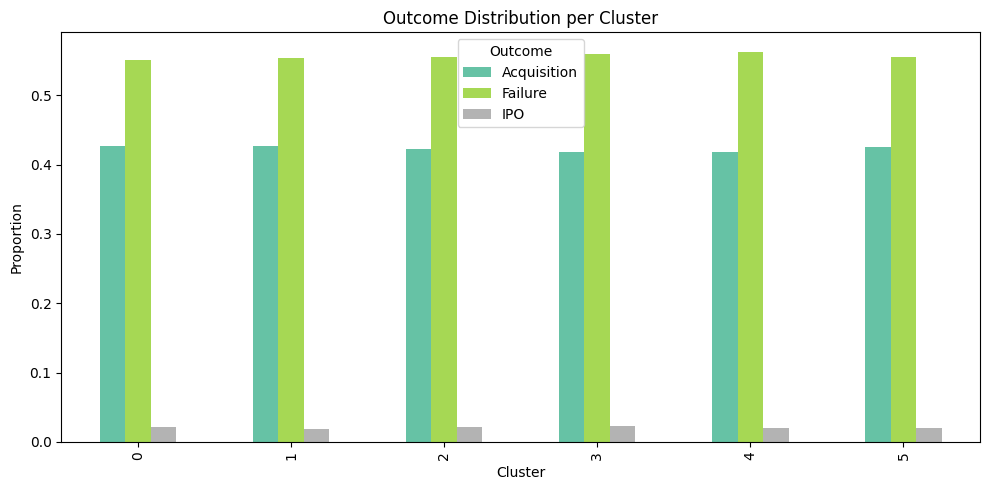

In [33]:
outcome_dist.plot(kind='bar', figsize=(10, 5), colormap='Set2')
plt.title('Outcome Distribution per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Proportion')
plt. legend(title='Outcome')
plt.tight_layout()
plt.show()